> **Purpose:** NJ on unbalanced birth-death trees.  
> **Data:** generated

# Figure 9 — Distance-based ($B$-matrix) clan partition with subsampling on a synthetic unbalanced (birth–death) tree

Uses the **distance-based partitioner** of Spectral-Top-Down-Recovery,
Appendix D (p. 2329, from ref [20]): the terminal nodes split into two clans
by the **sign pattern of the leading eigenvector** of the doubly-centred
distance matrix

$$B = (I - \mathbf{11}^\top/m)\, D\, (I - \mathbf{11}^\top/m).$$

This replaces the earlier classical-NJ reconstruction. We measure how well that
single bipartition survives uniform sub-sampling of $D$, as a function of the
sampling fraction $p$ and the number of taxa $n$:

- **`agreement`** — % of taxa whose clan label (sign of the leading eigenvector
  of $\hat B = (I-\mathbf{11}^\top/m)\,\hat D\,(I-\mathbf{11}^\top/m)$) matches
  the **full-data reference** partition (sign of the leading eigenvector of
  $B$). Orientation-invariant ($A|B \equiv B|A$); 50% is chance.
- **`dot`** — $|\langle \hat v_1, v_1\rangle|$ of the sign-aligned unit-norm
  leading eigenvectors: a continuous analog of the agreement.

Motivation (unchanged from the NJ version): test whether "more samples at fixed
$p$ should average down noise" shows up when the tree is **unbalanced**
(`birth_death`, birth_rate=1, death_rate=0) so distances are heterogeneous but
branch lengths stay $O(1)$ regardless of $n$. The reference partition $v_1$ is
recovered cleanly at $p=1$ for all $n$, so any degradation is attributable to
subsampling rather than topology resolution.

Runner: `src/runners/bpart_sweep.py`; plot: `scripts/plot_bpart_overlay.py`.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, json
from datetime import datetime
from pathlib import Path
from IPython.display import Image, display


_R = Path.cwd()
while _R.parent != _R and not (_R / "setup.py").exists():
    _R = _R.parent
_root = str(_R / "sub_sampled_fielder_vec")
if _root not in sys.path:
    sys.path.insert(0, _root)

# Drop any stale cached copies of our project modules so this cell picks up
# edits made since the kernel started. autoreload handles subsequent edits.
for _mod in [m for m in list(sys.modules) if m.startswith(('scripts.', 'src.'))]:
    del sys.modules[_mod]

from src.config.presets import custom_config
from src.runners.bpart_sweep import bpart_sweep_for_params
from scripts.plot_bpart_overlay import load_bpart_results, _load_sweep, _plot_overlay

In [2]:
# Shared sweep grid + launcher. Distance matrices are disk-cached
# (use_persistent_cache=True), so re-launching with the same
# (tree_model, n, L, mu, tree_kwargs) reuses the generated D from
# sub_sampled_fielder_vec/cache/distance_matrix/ instead of re-simulating.
TAXA   = [128, 256, 512, 1024, 2048, 4000]
SEQLEN = 10000
REPS   = 5
P_VALS = [1.0, 0.9, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]


def run_or_load(tree_model, tree_kwargs, run_dir=None, *,
                taxa=TAXA, seqlen=SEQLEN, reps=REPS, p_vals=P_VALS):
    """Launch a fresh bpart sweep (run_dir=None) or just return an existing dir."""
    if run_dir is None:
        name = (datetime.now().strftime('%Y%m%d-%H%M%S')
                + f'-bpart_{tree_model}_L{seqlen}')
        run_dir = Path(_root) / 'results' / 'runs' / name
        for n in taxa:
            cfg = custom_config(num_taxa=n, sequence_length=seqlen, mutation_rate=0.1,
                                tree_model=tree_model, seq_model='JC69',
                                p_values=p_vals, bootstrap_reps=reps,
                                sampling_method='uniform', matrix_kind='distance',
                                use_persistent_cache=True, **tree_kwargs)
            bpart_sweep_for_params(cfg, n, seqlen, str(run_dir / f'n{n}_L{seqlen}'))
    else:
        run_dir = Path(run_dir)
    print('sweep dir:', run_dir)
    return run_dir

## Choose: load or launch
Set `RUN_DIR` to an existing sweep directory to **load** prior results. Leave it `None` to **launch** a fresh sweep with the grid below.

In [3]:
# birth_death: set RUN_DIR to an existing bpart sweep to LOAD, or None to LAUNCH.
RUN_DIR = None
RUN_DIR = run_or_load('birth_death', {'birth_rate': 1.0, 'death_rate': 0.0},
                      run_dir=RUN_DIR)

BPART | INFO | Building ground truth (n=128, L=10000)...
CACHE_MANAGER | INFO | distance_matrix HIT: birth_death_L10000_birth_rate1p0000_death_rate0p0000_mu0p1000_n0128_num_taxa0128_seqJC69
BPART | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-150209-bpart_birth_death_L10000/n128_L10000/bpart_meta.json (0.1s, cache MISS)
BPART | INFO | Building ground truth (n=256, L=10000)...
CACHE_MANAGER | INFO | distance_matrix HIT: birth_death_L10000_birth_rate1p0000_death_rate0p0000_mu0p1000_n0256_num_taxa0256_seqJC69
BPART | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-150209-bpart_birth_death_L10000/n256_L10000/bpart_meta.json (0.3s, cache MISS)
BPART | INFO | Building ground truth (n=512, L=10000)...
CACHE_MANAGER | INFO | distance_matrix HIT: birth_death_L10000_birth_rate1p0000_death_rate0p0000_mu0p1000_n0512_num_taxa0512_seqJC69
BPART | INFO | Wrote /Users/itayg/PythonRe

## Clan-partition agreement & leading-eigenvector alignment vs $p$, per $n$

wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-150209-bpart_birth_death_L10000/bpart_overlay.png


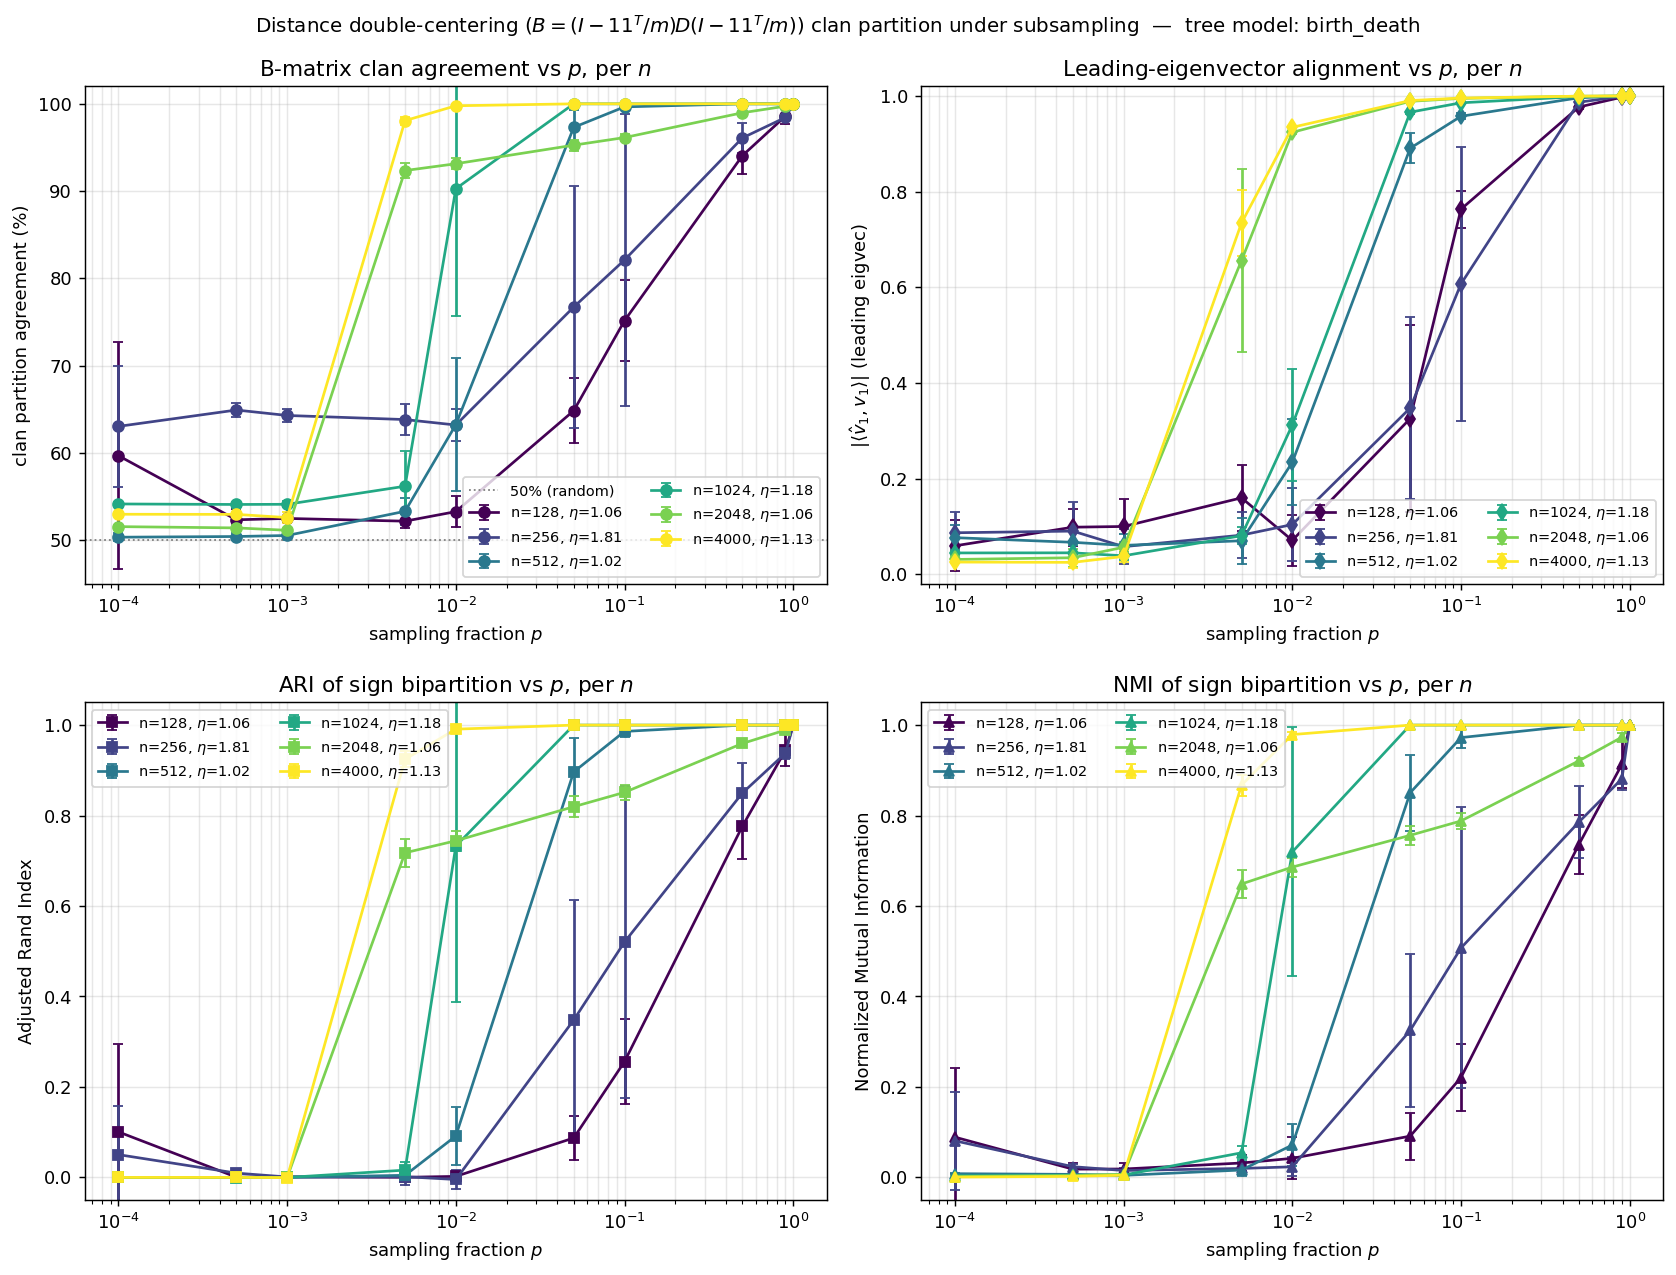

In [4]:
_plot_overlay(RUN_DIR, RUN_DIR / 'bpart_overlay.png')
display(Image(filename=str(RUN_DIR / 'bpart_overlay.png')))

## Agreement table (per $n$, per $p$)

In [5]:
import pandas as pd

def agreement_table(run_dir):
    loaded = _load_sweep(run_dir)
    records = []
    for r in loaded:
        for e in sorted(r['per_p'], key=lambda x: -x['p']):
            records.append({
                'n': r['n_taxa'], 'p': e['p'],
                'agreement_%': round(e['agreement_mean'], 1),
                'agreement_std': round(e['agreement_std'], 1),
                'dot': round(e['dot_mean'], 3),
                'ARI': round(e['ari_mean'], 3),
                'NMI': round(e['nmi_mean'], 3),
            })
    df = pd.DataFrame.from_records(records)
    pivot = df.pivot(index='p', columns='n', values='agreement_%').sort_index(ascending=False)
    print('Clan partition agreement (%) — rows: p (desc), cols: n')
    display(pivot)
    return df

agreement_table(RUN_DIR)

Clan partition agreement (%) — rows: p (desc), cols: n


n,128,256,512,1024,2048,4000
p,,,,,,
1.0000,100.0,100.0,100.0,100.0,100.0,100.0
0.9000,98.6,98.4,100.0,100.0,99.7,100.0
0.5000,94.1,96.1,100.0,100.0,99.0,100.0
0.1000,75.2,82.1,99.6,100.0,96.1,100.0
0.0500,64.8,76.7,97.3,100.0,95.3,100.0
0.0100,53.3,63.2,63.2,90.3,93.1,99.8
0.0050,52.2,63.8,53.3,56.2,92.4,98.1
0.0010,52.5,64.3,50.5,54.1,51.1,52.6
0.0005,52.3,64.9,50.4,54.1,51.4,53.0


,n,p,agreement_%,agreement_std,dot,ARI,NMI
0,128,1.0000,100.0,0.0,1.000,1.000,1.000
1,128,0.9000,98.6,0.9,0.997,0.944,0.913
2,128,0.5000,94.1,2.1,0.977,0.777,0.736
3,128,0.1000,75.2,4.6,0.763,0.256,0.221
4,128,0.0500,64.8,3.7,0.326,0.087,0.091
5,128,0.0100,53.3,1.8,0.071,0.002,0.042
6,128,0.0050,52.2,0.8,0.160,0.000,0.032
7,128,0.0010,52.5,1.6,0.100,0.001,0.019
8,128,0.0005,52.3,1.2,0.099,0.001,0.018
9,128,0.0001,59.7,13.0,0.060,0.101,0.089


# Kingman tree

Same B-matrix clan-partition experiment on a **Kingman coalescent** tree
(`tree_model='kingman'`, `pop_size=1.0`) instead of birth–death.

**Why this is worth a second look.** Classical NJ failed on Kingman at $p=1$
for $n \geq 256$ because NJ must resolve *every* tip branch, and Kingman
tip-branch lengths shrink as $O(1/n^2)$ — so the truth itself was
unrecoverable and the subsampling signal was confounded by topology
resolution. The B-method is different: it only recovers the **dominant (deep)
split** from the leading eigenvector of $B=(I-\mathbf{11}^\top/m)D(I-\mathbf{11}^\top/m)$,
which Kingman keeps $O(1)$. So the short-tip problem should bite far less here.

**Guard against the confound anyway:** we read off the $p=1$ row of the table
below. If agreement $\approx 100\%$ and ARI $\approx 1$ at $p=1$, the reference
split is clean and the degradation curve is attributable to subsampling. If
not, the Kingman top split is genuinely under-resolved at this $(n, L)$ and the
curve should be read as such — not as a subsampling effect.

BPART | INFO | Building ground truth (n=128, L=10000)...
CACHE_MANAGER | INFO | distance_matrix HIT: kingman_L10000_mu0p1000_n0128_num_taxa0128_pop_size1p0000_seqJC69
BPART | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-151136-bpart_kingman_L10000/n128_L10000/bpart_meta.json (0.1s, cache MISS)
BPART | INFO | Building ground truth (n=256, L=10000)...
CACHE_MANAGER | INFO | distance_matrix HIT: kingman_L10000_mu0p1000_n0256_num_taxa0256_pop_size1p0000_seqJC69
BPART | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-151136-bpart_kingman_L10000/n256_L10000/bpart_meta.json (0.3s, cache MISS)
BPART | INFO | Building ground truth (n=512, L=10000)...
CACHE_MANAGER | INFO | distance_matrix HIT: kingman_L10000_mu0p1000_n0512_num_taxa0512_pop_size1p0000_seqJC69
BPART | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-1511

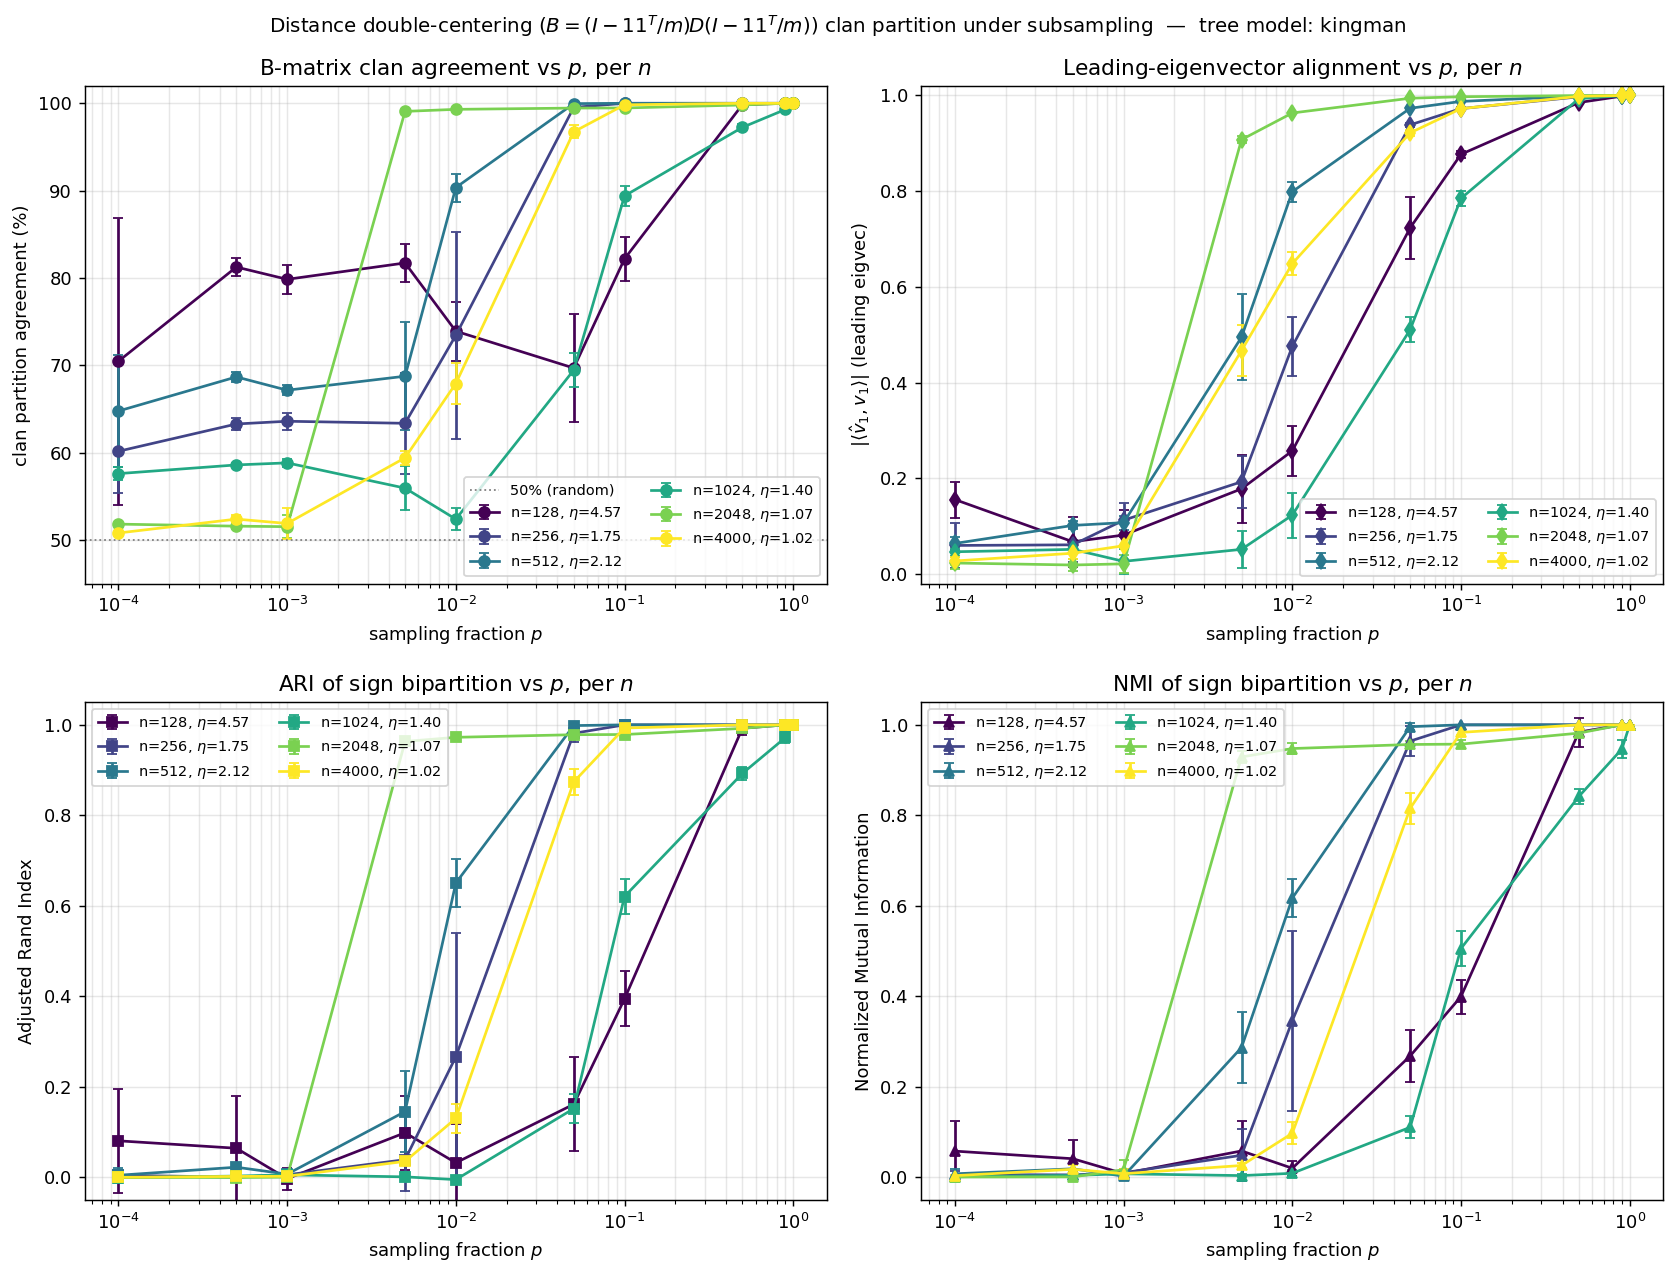

Clan partition agreement (%) — rows: p (desc), cols: n


n,128,256,512,1024,2048,4000
p,,,,,,
1.0000,100.0,100.0,100.0,100.0,100.0,100.0
0.9000,100.0,100.0,100.0,99.3,100.0,100.0
0.5000,99.8,100.0,100.0,97.2,99.8,100.0
0.1000,82.2,100.0,100.0,89.4,99.5,99.8
0.0500,69.7,99.5,100.0,69.5,99.5,96.7
0.0100,73.9,73.4,90.4,52.4,99.3,67.9
0.0050,81.7,63.4,68.8,55.9,99.1,59.4
0.0010,79.8,63.6,67.1,58.8,51.5,51.9
0.0005,81.2,63.3,68.7,58.6,51.6,52.4


,n,p,agreement_%,agreement_std,dot,ARI,NMI
0,128,1.0000,100.0,0.0,1.000,1.000,1.000
1,128,0.9000,100.0,0.0,0.998,1.000,1.000
2,128,0.5000,99.8,0.3,0.985,0.993,0.984
3,128,0.1000,82.2,2.5,0.877,0.394,0.400
4,128,0.0500,69.7,6.2,0.723,0.162,0.268
5,128,0.0100,73.9,3.4,0.257,0.032,0.020
6,128,0.0050,81.7,2.1,0.178,0.099,0.059
7,128,0.0010,79.8,1.7,0.081,-0.003,0.008
8,128,0.0005,81.2,1.0,0.068,0.064,0.041
9,128,0.0001,70.5,16.4,0.156,0.081,0.058


In [6]:
# kingman: set KINGMAN_RUN_DIR to an existing sweep to LOAD, or None to LAUNCH.
KINGMAN_RUN_DIR = None
KINGMAN_RUN_DIR = run_or_load('kingman', {'pop_size': 1.0},
                              run_dir=KINGMAN_RUN_DIR)

_plot_overlay(KINGMAN_RUN_DIR, KINGMAN_RUN_DIR / 'bpart_overlay.png')
display(Image(filename=str(KINGMAN_RUN_DIR / 'bpart_overlay.png')))
agreement_table(KINGMAN_RUN_DIR)

# Kingman by η bin (η ∈ {1, 5, 10, 15})

The per-$n$ Kingman curves above let the top-split imbalance
$\eta = \max(n_1,n_2)/\min(n_1,n_2)$ fall wherever a random tree puts it, so
they mix the subsampling effect with an uncontrolled $\eta$.

To **control** for $\eta$ — and stay aligned with the
[`eta_pool_sweep_per_n_median`](../02_real_data_sweeps/eta_pool_sweep_per_n_median.ipynb)
framework — this section reuses the pre-built $\eta$-binned Kingman pool in
`cache/pool_sample/` (targets $\{1,5,10,15\}$). Each pooled sample stores the JC
similarity $M$, so the B-method distance is recovered losslessly as
$D=-\log M$ (no re-simulation). We run the same subsampling sweep on every
pooled tree and average per bin.

**Layout (mirrors Fig 5 / Fig 6 of the median notebook):** instead of one
crowded overlay, we draw two grids per metric —
- **per $n$**: one subplot per $n$, one curve per $\eta$;
- **per $\eta$**: one subplot per $\eta$, one curve per $n$.

We show `agreement` (%) and `ARI`. Larger $\eta$ shrinks the CBM spectral margin
($\text{margin}=\rho-\eta\,S_{\text{out}}^{\max}$), so the high-$\eta$ curves
should need a larger $p$ to recover the split — but `agreement` is inflated for
large $\eta$ by the dominant-clan majority, so read `ARI` (chance-corrected) for
the imbalanced bins.

BPART_ETA | INFO |   n=500 eta~1: 20 samples × 1 reps
BPART_ETA | INFO |     0/20 samples from cache
BPART_ETA | INFO |   n=500 eta~5: 20 samples × 1 reps
BPART_ETA | INFO |     0/20 samples from cache
BPART_ETA | INFO |   n=500 eta~10: 20 samples × 1 reps
BPART_ETA | INFO |     0/20 samples from cache
BPART_ETA | INFO |   n=500 eta~15: 20 samples × 1 reps
BPART_ETA | INFO |     0/20 samples from cache
BPART_ETA | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-151913-bpart_eta_pool_kingman_L10000/bpart_eta_pool_n500.json
BPART_ETA | INFO |   n=1000 eta~1: 10 samples × 1 reps
BPART_ETA | INFO |     0/10 samples from cache
BPART_ETA | INFO |   n=1000 eta~5: 10 samples × 1 reps
BPART_ETA | INFO |     0/10 samples from cache
BPART_ETA | INFO |   n=1000 eta~10: 10 samples × 1 reps
BPART_ETA | INFO |     0/10 samples from cache
BPART_ETA | INFO |   n=1000 eta~15: 10 samples × 1 reps
BPART_ETA | INFO |     0/10 samples from cache
BPA

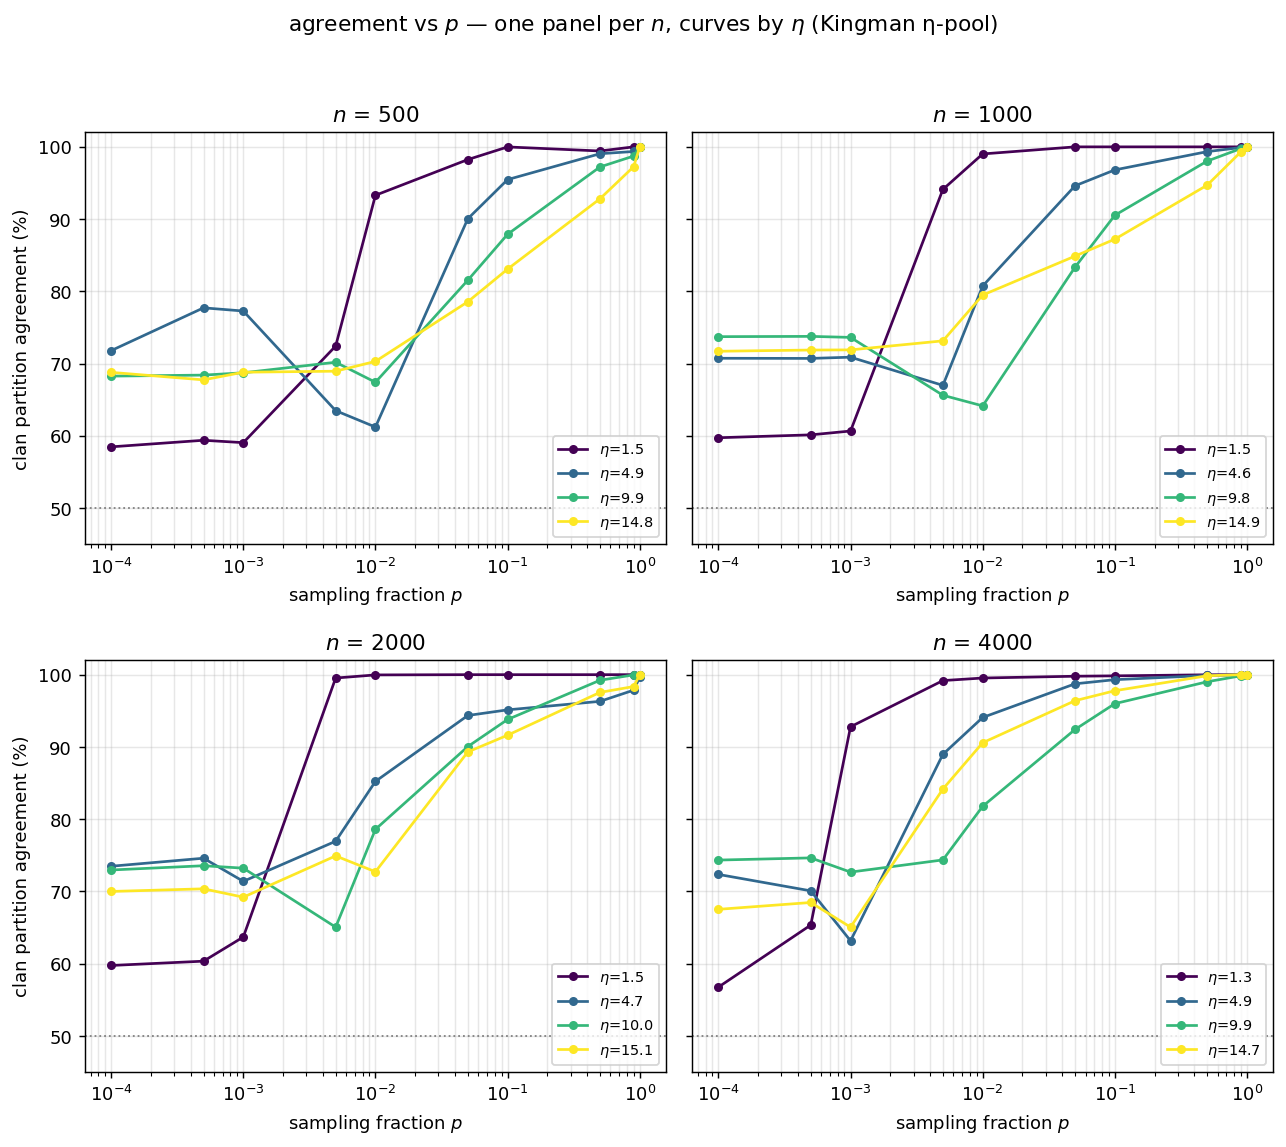

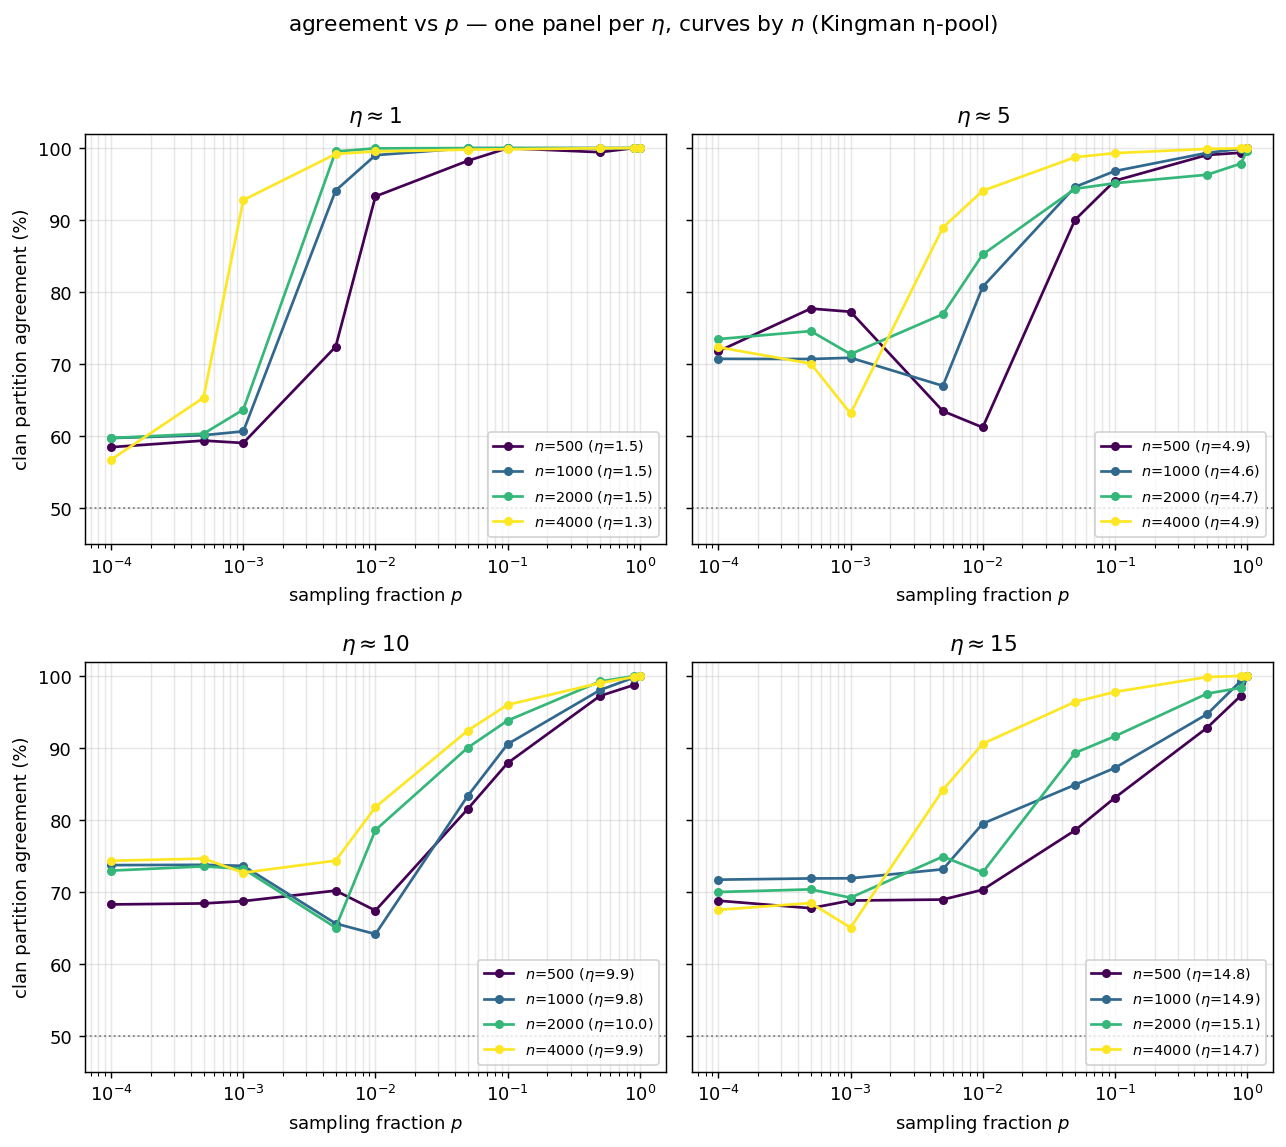

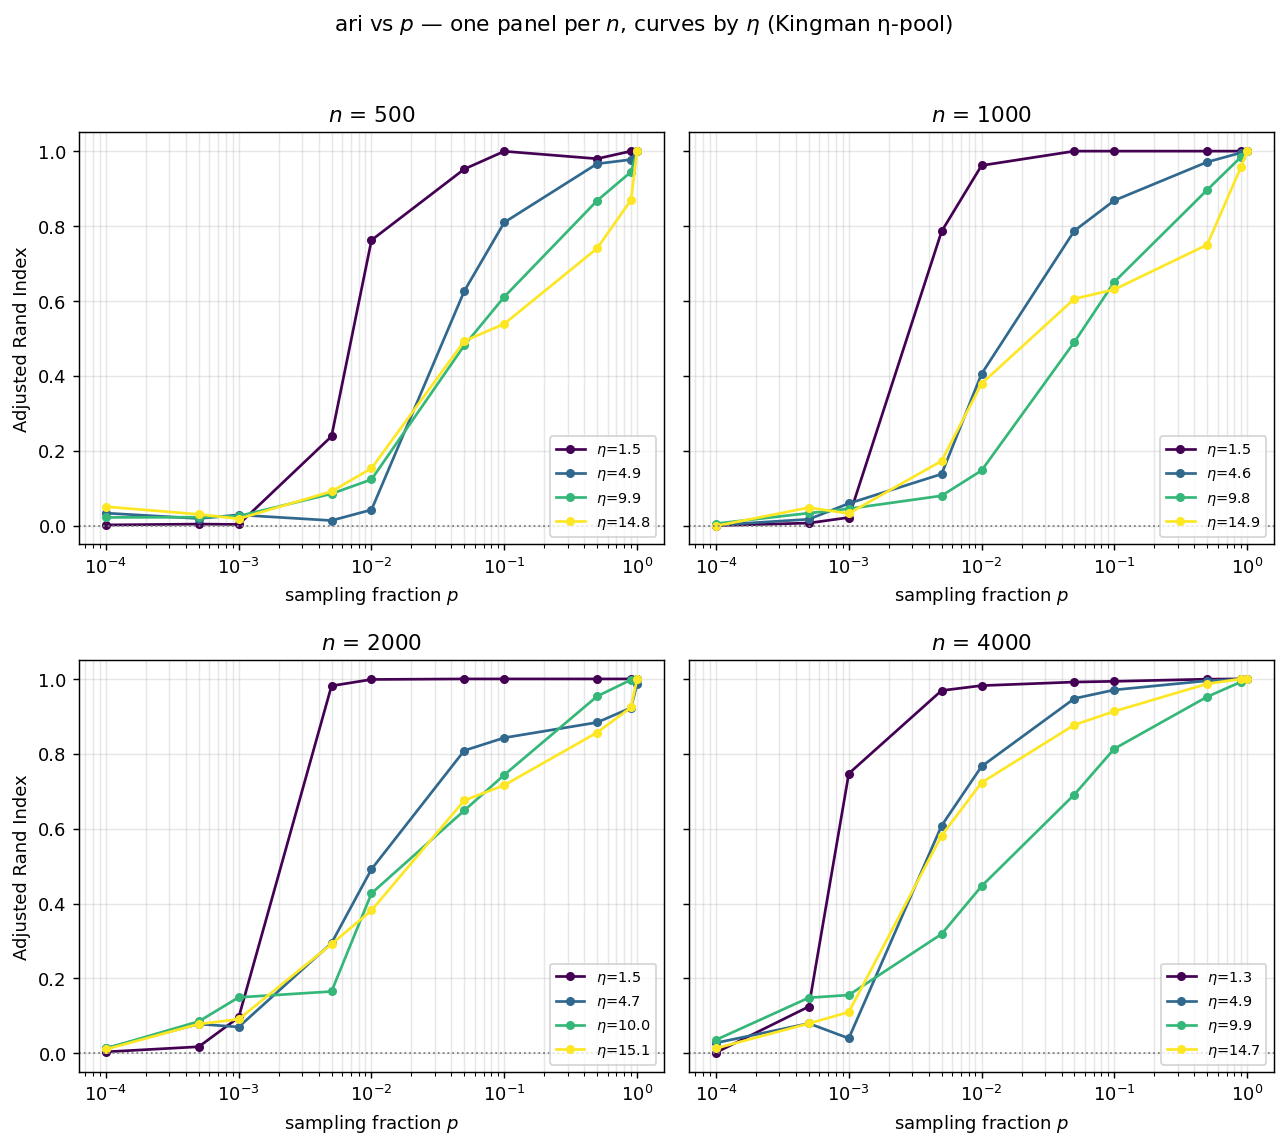

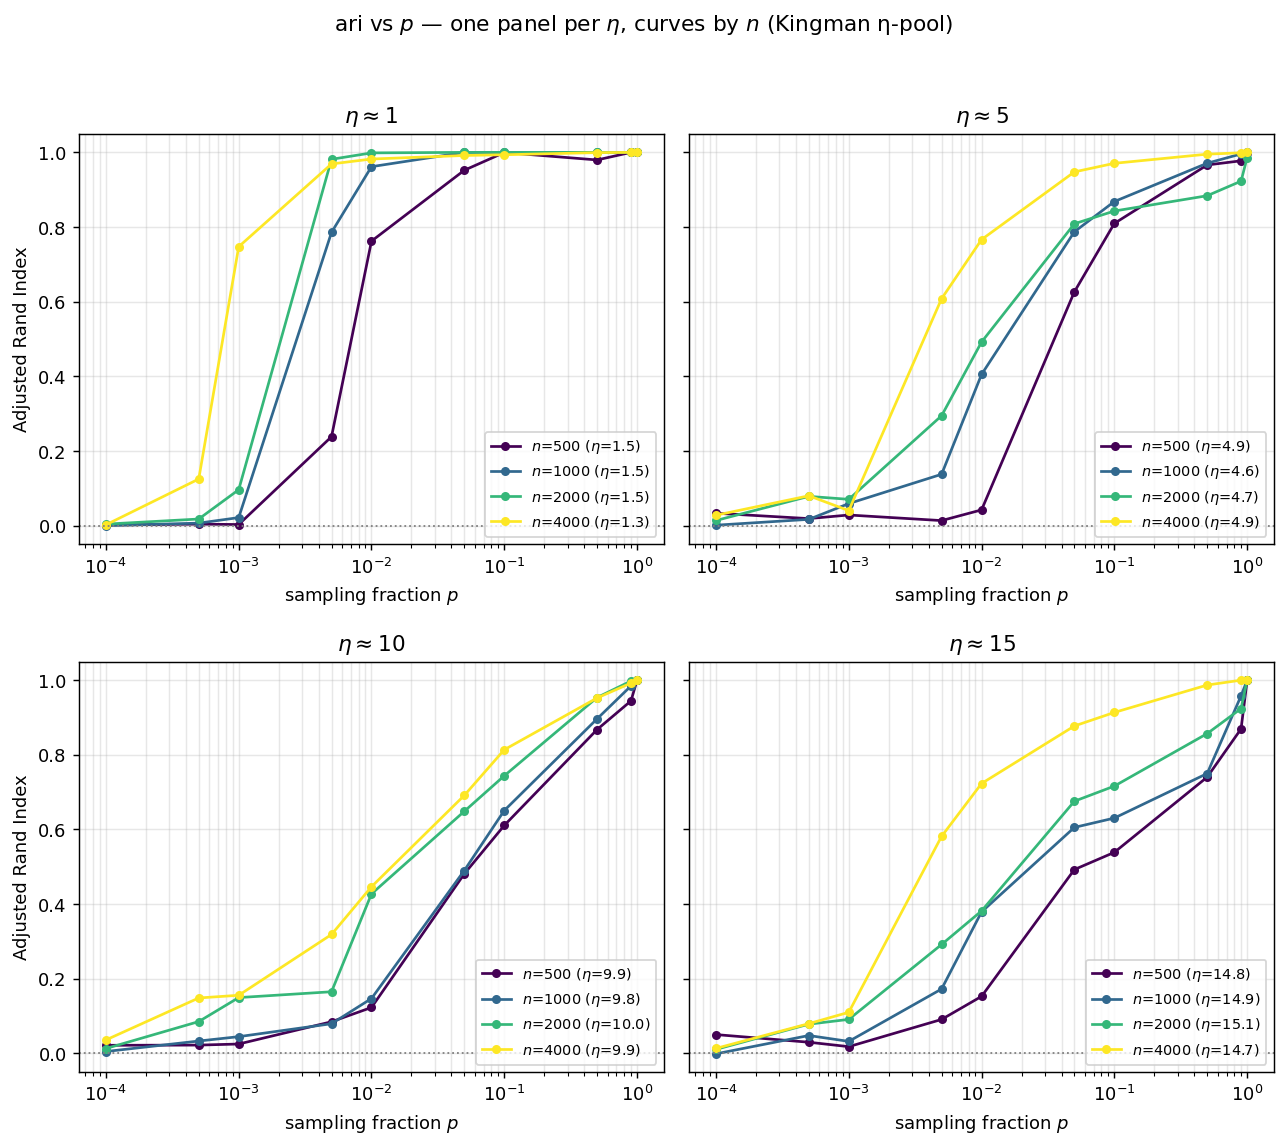

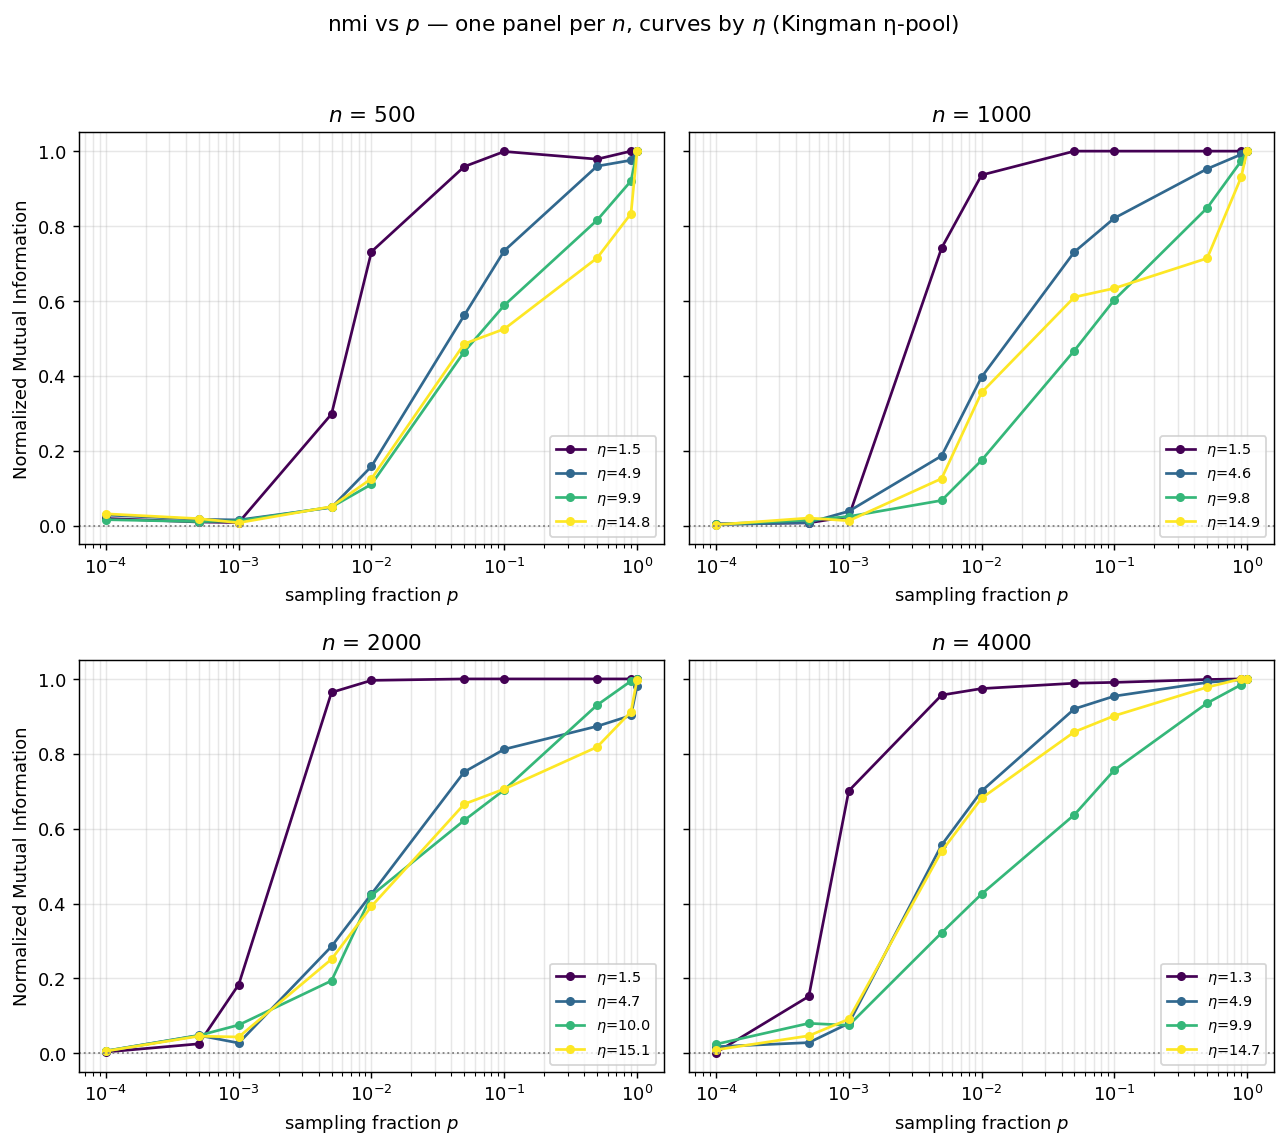

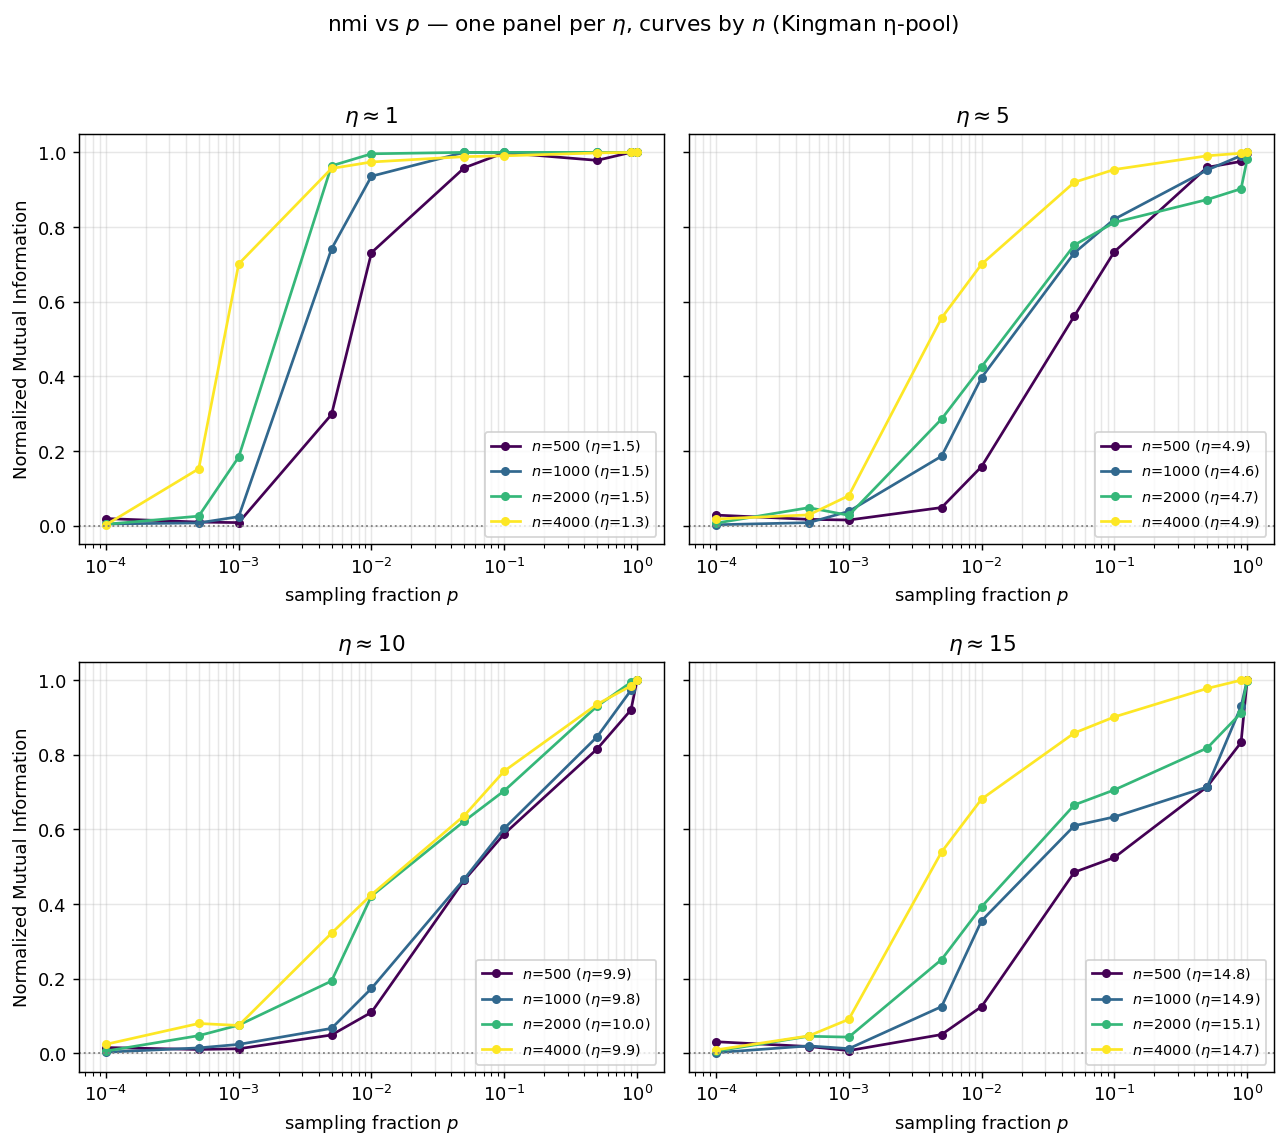

eta-pool dir: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-151913-bpart_eta_pool_kingman_L10000


In [7]:
from src.runners.bpart_eta_pool import bpart_eta_pool_for_n
from scripts.plot_bpart_eta_grid import plot_per_n, plot_per_eta

# Set ETA_POOL_DIR to an existing run to LOAD, or None to LAUNCH (reuses pooled
# trees, so it only subsamples + eigendecomposes — no sequence re-simulation).
ETA_POOL_DIR  = None
ETA_POOL_N    = [500, 1000, 2000, 4000]   # n with pre-built kingman eta pools
ETA_POOL_ETAS = (1, 5, 10, 15)            # match eta_pool_sweep_per_n_median

if ETA_POOL_DIR is None:
    ETA_POOL_DIR = (Path(_root) / 'results' / 'runs'
                    / (datetime.now().strftime('%Y%m%d-%H%M%S')
                       + '-bpart_eta_pool_kingman_L10000'))
    for n in ETA_POOL_N:
        bpart_eta_pool_for_n(n, str(ETA_POOL_DIR), eta_targets=ETA_POOL_ETAS, reps=1)
else:
    ETA_POOL_DIR = Path(ETA_POOL_DIR)

# Two layouts (cf. eta_pool_sweep_per_n_median Fig 5 / Fig 6), per metric:
#   per-n   → one subplot per n, curves by η
#   per-eta → one subplot per η, curves by n
# agreement is majority-inflated at high η, so we also show ARI + NMI (chance/MI based).
for metric in ("agreement", "ari", "nmi"):
    fn = plot_per_n(ETA_POOL_DIR, ETA_POOL_DIR / f'bpart_per_n_{metric}.png',
                    metric=metric, title_extra=" (Kingman η-pool)")
    fe = plot_per_eta(ETA_POOL_DIR, ETA_POOL_DIR / f'bpart_per_eta_{metric}.png',
                      metric=metric, title_extra=" (Kingman η-pool)")
    display(Image(filename=str(fn)))
    display(Image(filename=str(fe)))
print('eta-pool dir:', ETA_POOL_DIR)

# Synthetic imbalanced tree (flat CBM, η controlled exactly)

The Kingman / birth–death sweeps above let the topology decide the top-split
imbalance η. To pin η down — exactly as the
[`nonbalanced_flat_cbm`](../sec5_empirical/synthesized/nonbalanced_flat_cbm.ipynb) figure does
in *similarity* space — this section runs the same B-matrix clan partition on a
**synthetic flat-CBM distance matrix**:

$$D_{ij} = d_{\text{in}}\ (\text{same clan}),\qquad D_{ij}=d_{\text{out}}\ (\text{across}),\qquad D_{ii}=0,$$

with $d=-\log S$ (JC convention, $S_{\text{in}}=0.9$, $S_{\text{out}}=0.05$) and
clan sizes $(n_1,n_2)$ sized so $\eta=\max/\min$ hits each target exactly. No
sequences are simulated, so the reference split $v_1$ is the *true* clan
partition by construction — every drop in agreement is a pure sub-sampling
artifact at a **known** η, with zero topology-resolution confound.

Runner: `src/runners/bpart_synthetic.py`. Output schema matches `bpart_eta_pool`,
so the same per-$n$ / per-$\eta$ grid layout as the Kingman section applies
(Fig 5 / Fig 6 style: per-$n$ subplots with curves by $\eta$, and per-$\eta$
subplots with curves by $n$).

**Read:** at fixed $n$, larger η shrinks the CBM spectral margin
($\rho-\eta S_{\text{out}}^{\max}$), so high-η curves should need a larger $p$
to recover the split — but note `agreement` (%) is inflated for large η by the
dominant-clan majority, so cross-check ARI, which is imbalance-corrected.


BPART_SYNTH | INFO |   n=128 eta~1: n1=64 n2=64 (eta=1.00) x 5 reps
BPART_SYNTH | INFO |     cache MISS
BPART_SYNTH | INFO |   n=128 eta~5: n1=21 n2=107 (eta=5.10) x 5 reps
BPART_SYNTH | INFO |     cache MISS
BPART_SYNTH | INFO |   n=128 eta~10: n1=12 n2=116 (eta=9.67) x 5 reps
BPART_SYNTH | INFO |     cache MISS
BPART_SYNTH | INFO |   n=128 eta~15: n1=8 n2=120 (eta=15.00) x 5 reps
BPART_SYNTH | INFO |     cache MISS
BPART_SYNTH | INFO | Wrote /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-172537-bpart_synthetic_flatcbm/bpart_eta_pool_n128.json
BPART_SYNTH | INFO |   n=256 eta~1: n1=128 n2=128 (eta=1.00) x 5 reps
BPART_SYNTH | INFO |     cache MISS
BPART_SYNTH | INFO |   n=256 eta~5: n1=43 n2=213 (eta=4.95) x 5 reps
BPART_SYNTH | INFO |     cache MISS
BPART_SYNTH | INFO |   n=256 eta~10: n1=23 n2=233 (eta=10.13) x 5 reps
BPART_SYNTH | INFO |     cache MISS
BPART_SYNTH | INFO |   n=256 eta~15: n1=16 n2=240 (eta=15.00) x 5 reps
BPART_SYNTH |

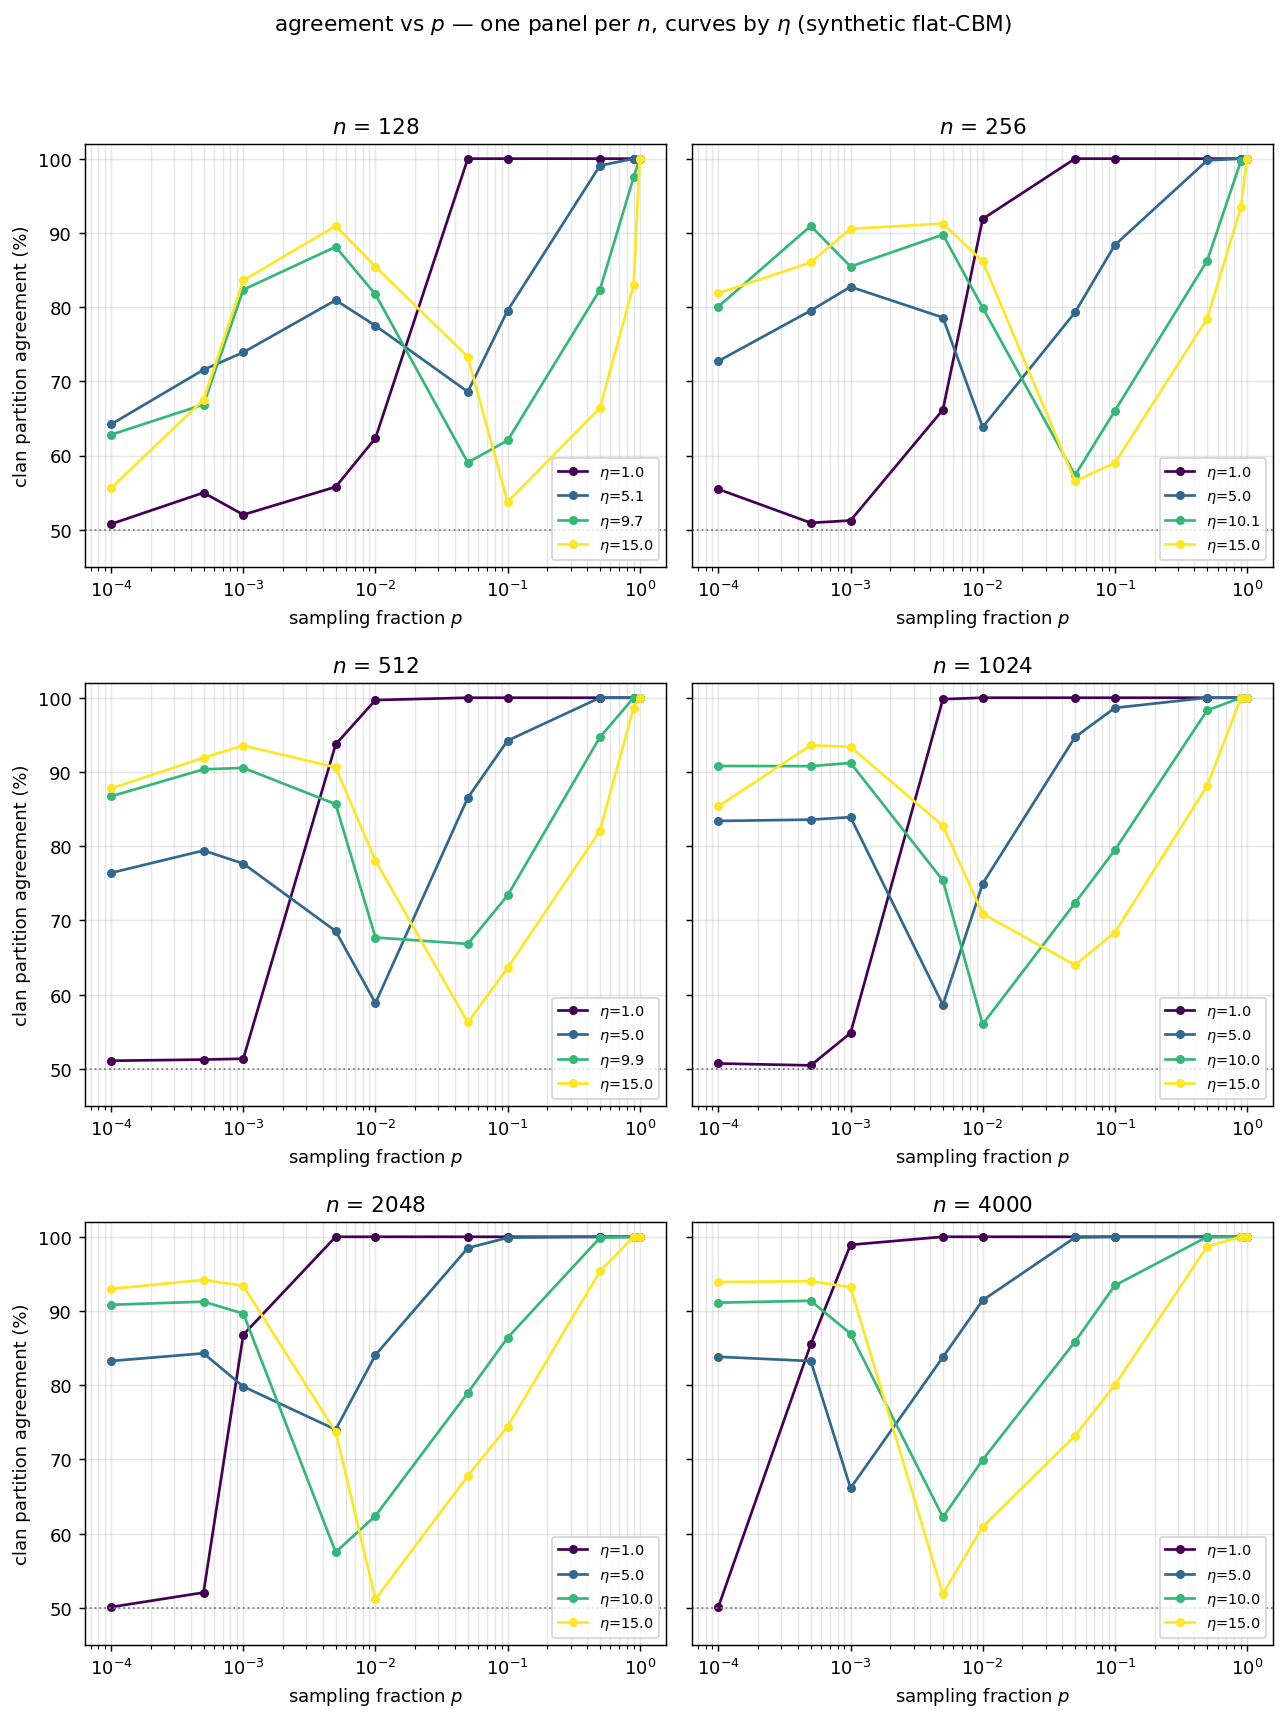

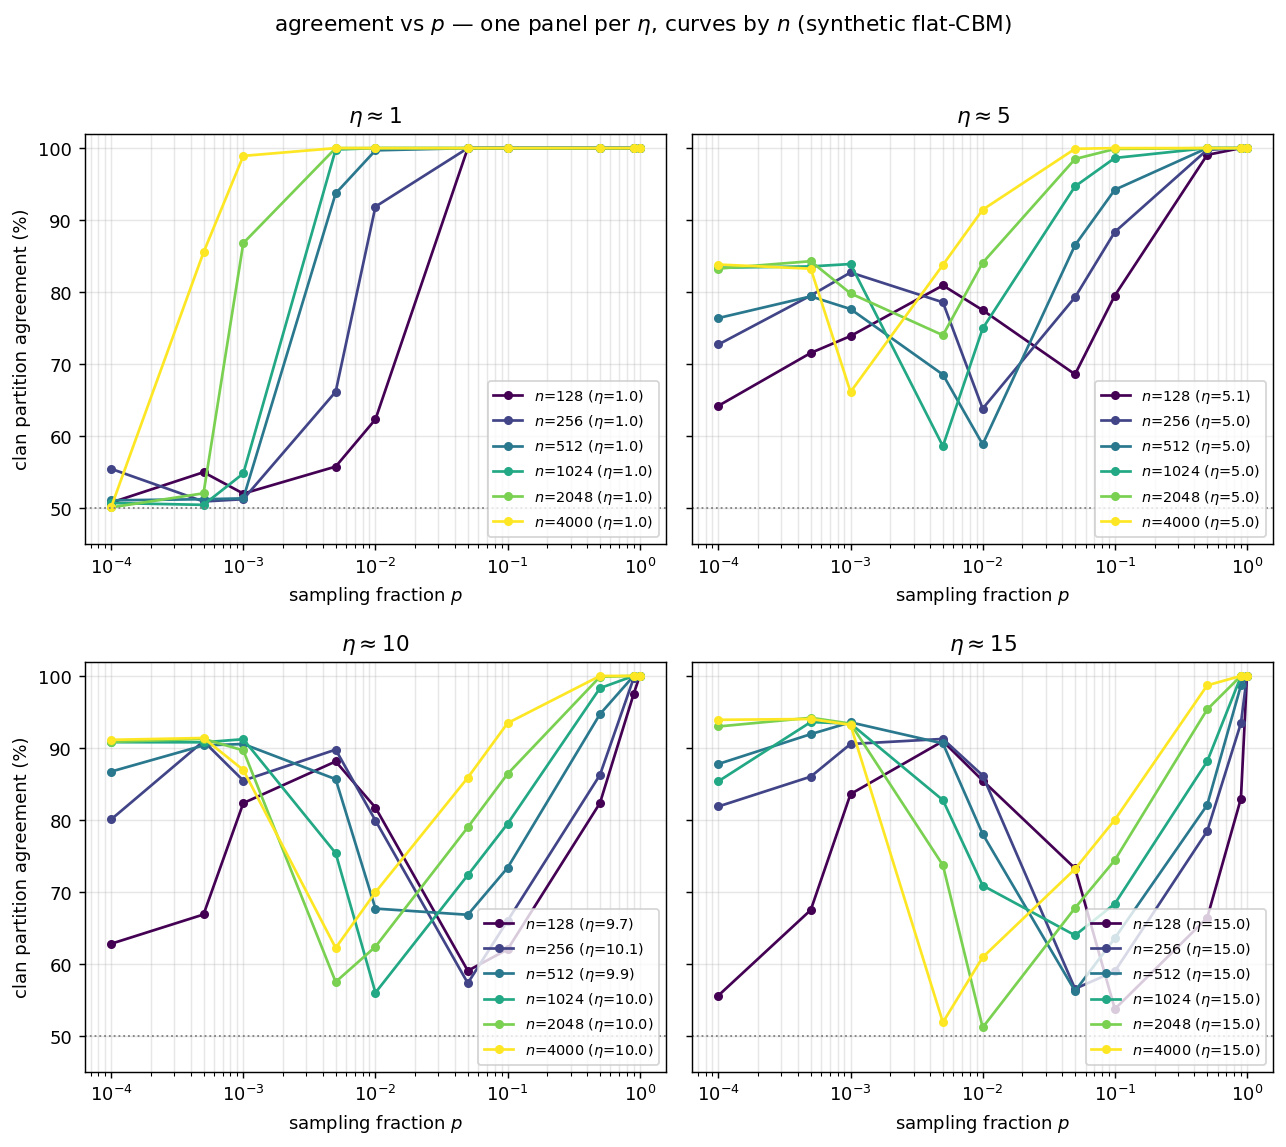

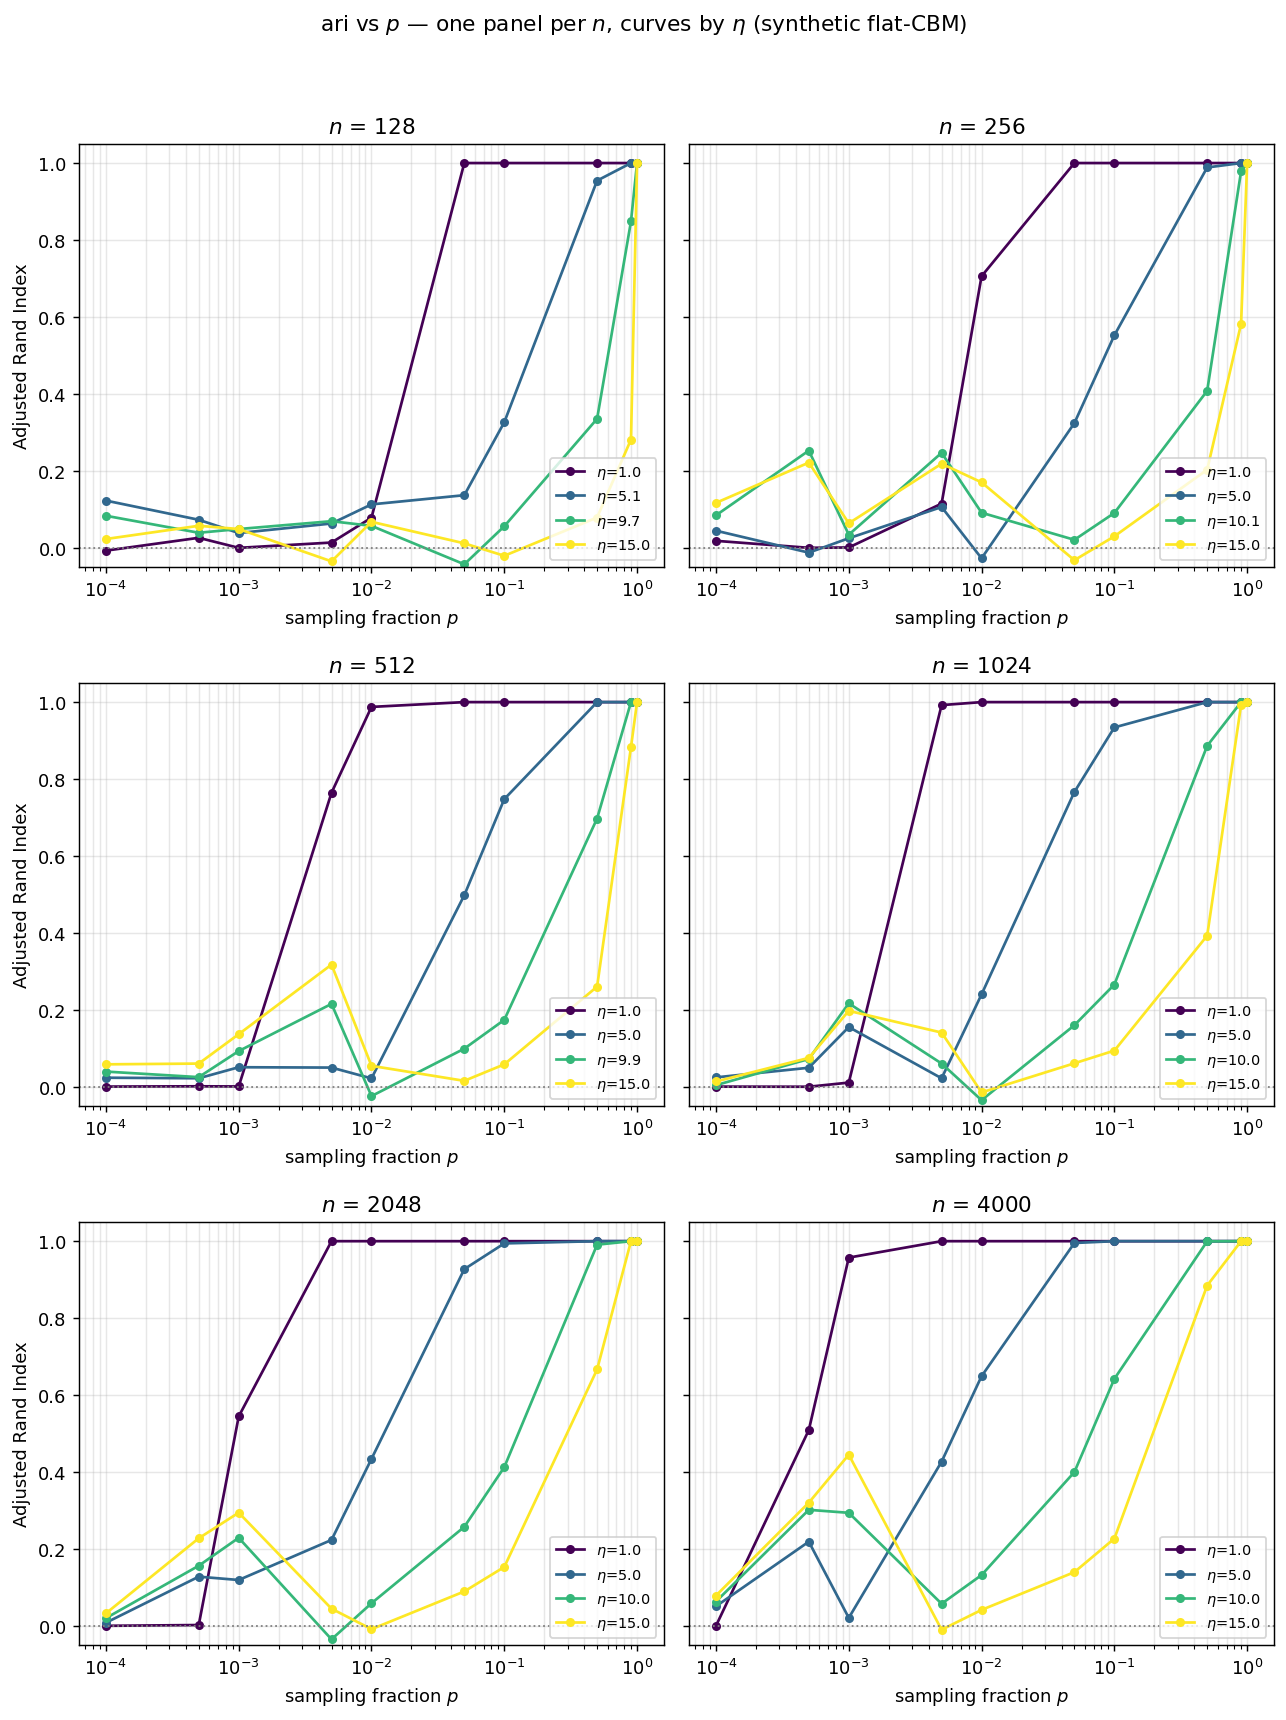

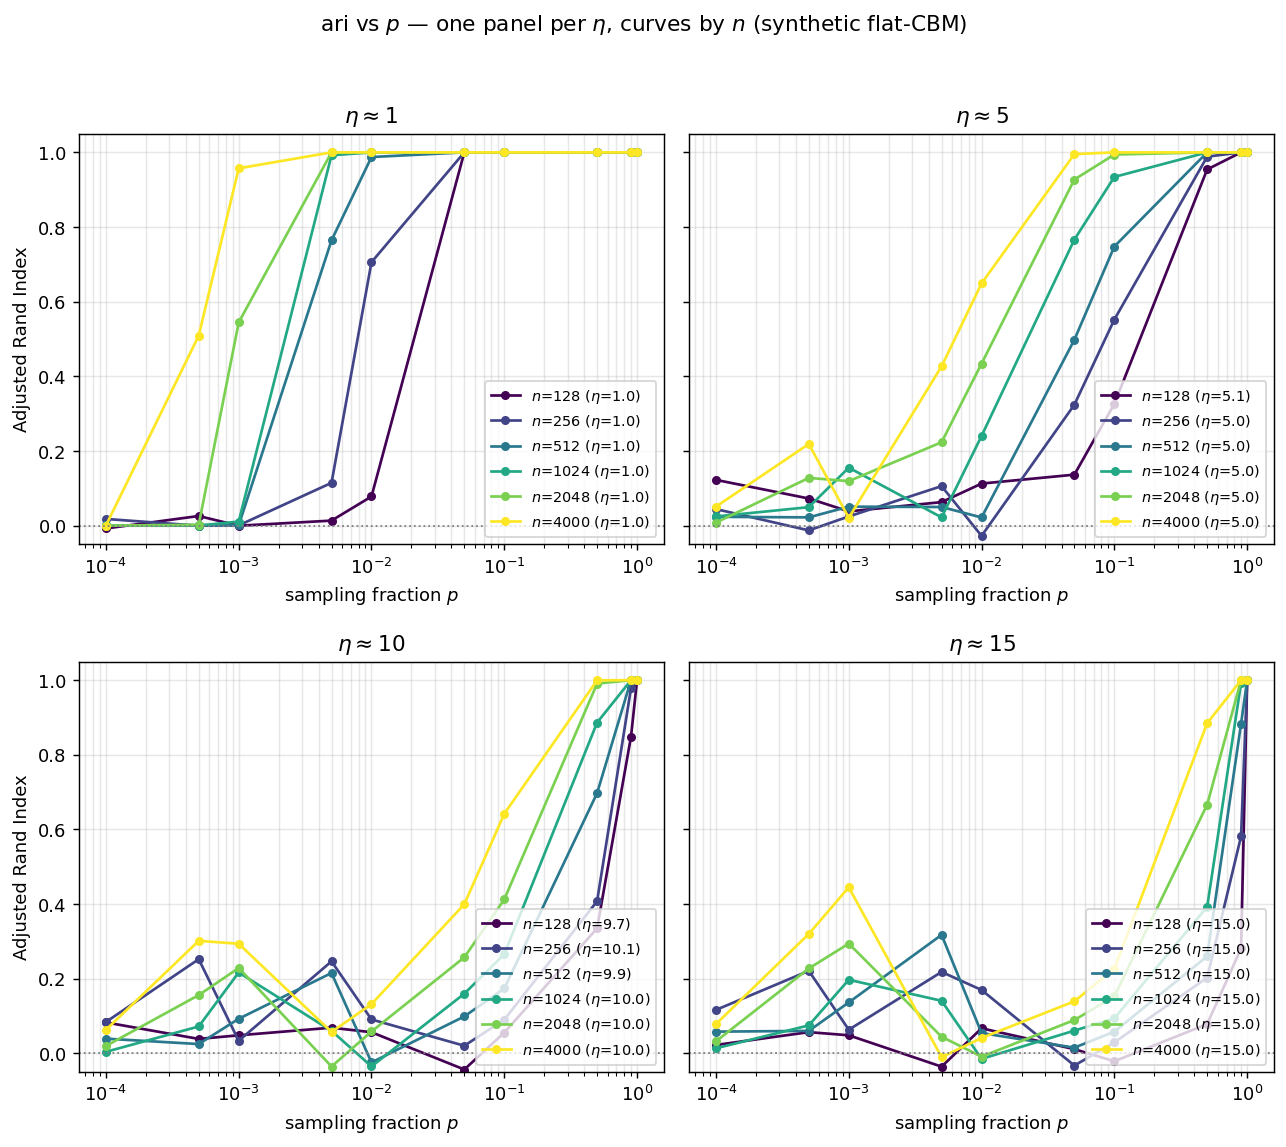

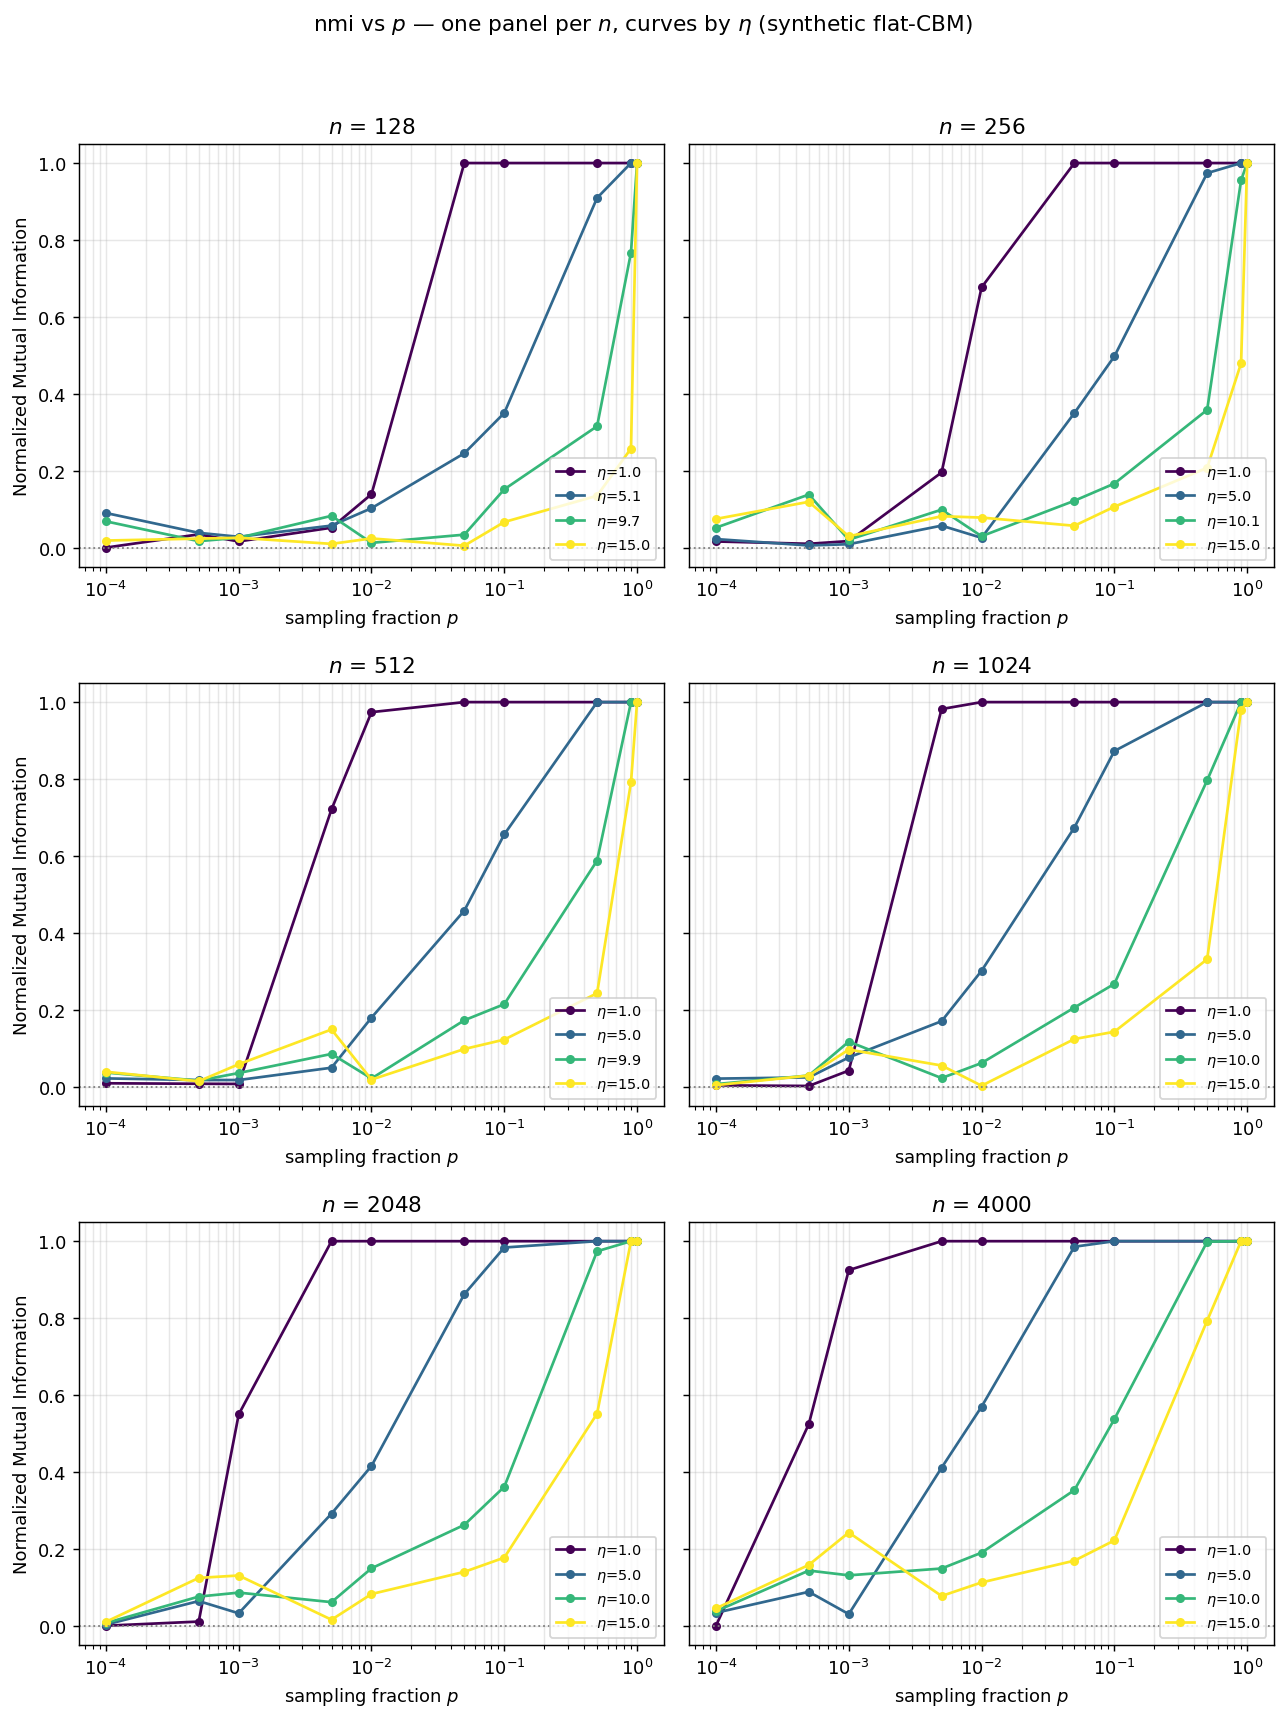

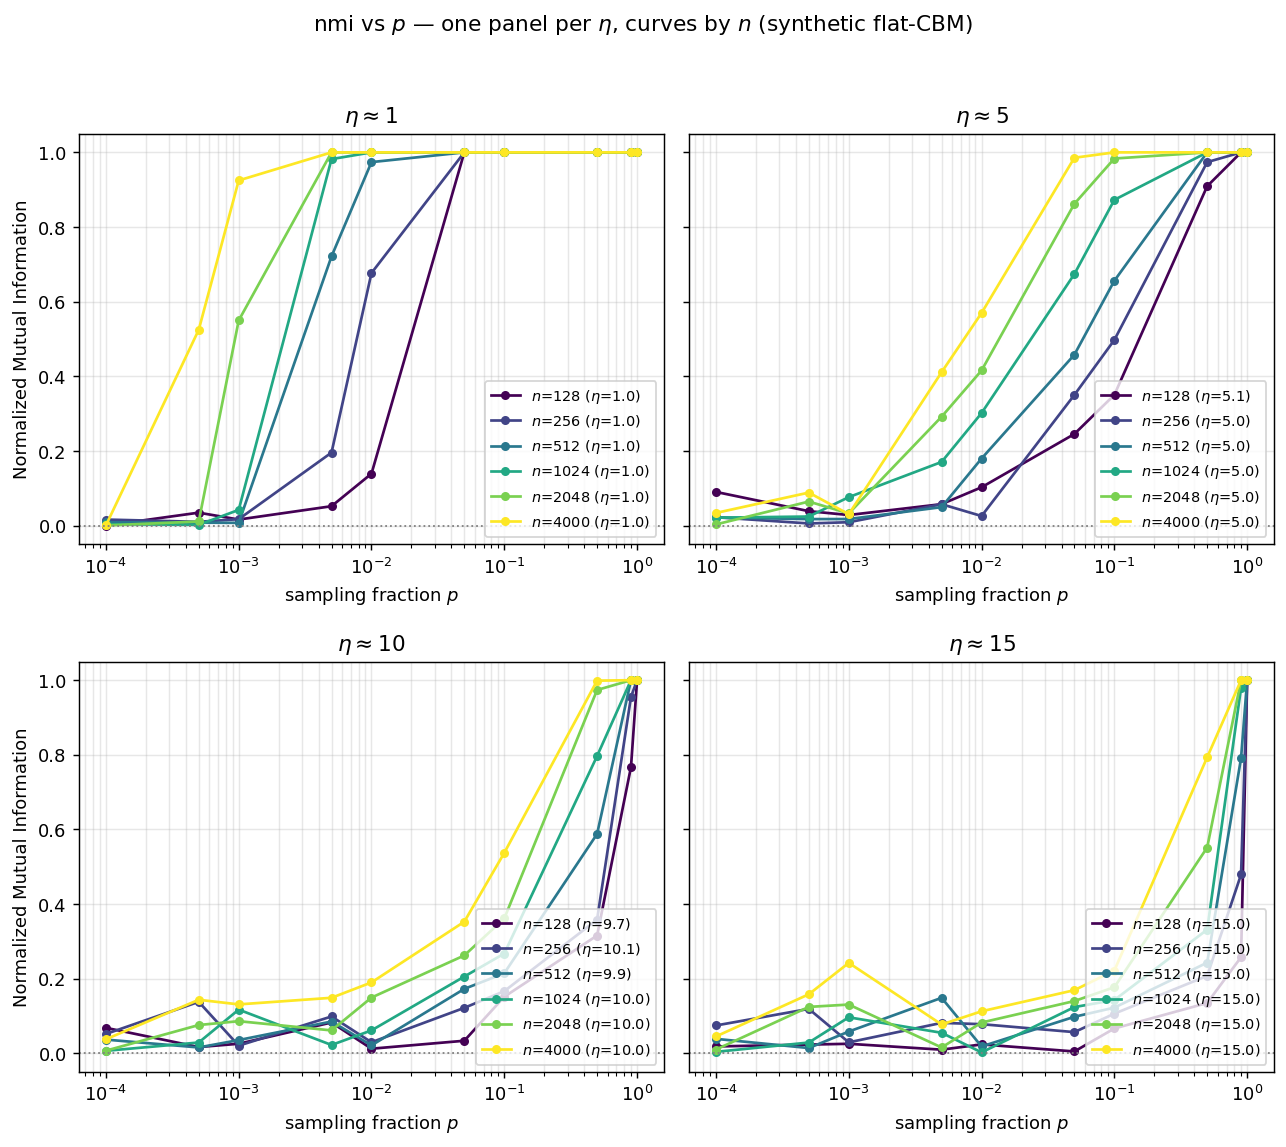

synthetic dir: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/results/runs/20260609-172537-bpart_synthetic_flatcbm


In [8]:
# Self-contained: bootstrap sys.path + imports so this cell runs regardless of
# whether the setup cells above were executed first.
import os, sys
from datetime import datetime
from pathlib import Path
from IPython.display import Image, display

_R = Path.cwd()
while _R.parent != _R and not (_R / "setup.py").exists():
    _R = _R.parent
_root = str(_R / "sub_sampled_fielder_vec")
if _root not in sys.path:
    sys.path.insert(0, _root)

from src.runners.bpart_synthetic import bpart_synthetic_for_n
from scripts.plot_bpart_eta_grid import plot_per_n, plot_per_eta

# Fall back to standalone defaults if the shared grid cell above wasn't run.
REPS   = globals().get('REPS', 5)
P_VALS = globals().get('P_VALS',
    [1.0, 0.9, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001])

# Set SYNTH_DIR to an existing run to LOAD, or None to LAUNCH. The synthetic
# distance matrix is built in-memory (no simulation, no cache needed), so a
# fresh launch is fast even at n=4000.
SYNTH_DIR    = None
SYNTH_N      = [128, 256, 512, 1024, 2048, 4000]
SYNTH_ETAS   = (1, 5, 10, 15)   # exact η, matched to the Kingman η-pool bins
SYNTH_PVALS  = P_VALS

if SYNTH_DIR is None:
    SYNTH_DIR = (Path(_root) / 'results' / 'runs'
                 / (datetime.now().strftime('%Y%m%d-%H%M%S')
                    + '-bpart_synthetic_flatcbm'))
    for n in SYNTH_N:
        bpart_synthetic_for_n(n, str(SYNTH_DIR), eta_targets=SYNTH_ETAS,
                              s_in=0.9, s_out=0.05, reps=REPS, p_values=SYNTH_PVALS)
else:
    SYNTH_DIR = Path(SYNTH_DIR)

# Same two-grid layout as the Kingman η-pool section (per n / per η), per metric.
for metric in ("agreement", "ari", "nmi"):
    fn = plot_per_n(SYNTH_DIR, SYNTH_DIR / f'bpart_per_n_{metric}.png',
                    metric=metric, title_extra=" (synthetic flat-CBM)")
    fe = plot_per_eta(SYNTH_DIR, SYNTH_DIR / f'bpart_per_eta_{metric}.png',
                      metric=metric, title_extra=" (synthetic flat-CBM)")
    display(Image(filename=str(fn)))
    display(Image(filename=str(fe)))
print('synthetic dir:', SYNTH_DIR)